In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.decomposition import PCA
from scipy.stats import zscore

In [2]:
# reading the CSV file into pandas dataframe
vehicle = pd.read_csv("vehicle.csv")

In [3]:
vehicle.head(5)
#checking the  features present in the datset

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [4]:
vehicle.info()
vehicle.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
compactness                    846 non-null int64
circularity                    841 non-null float64
distance_circularity           842 non-null float64
radius_ratio                   840 non-null float64
pr.axis_aspect_ratio           844 non-null float64
max.length_aspect_ratio        846 non-null int64
scatter_ratio                  845 non-null float64
elongatedness                  845 non-null float64
pr.axis_rectangularity         843 non-null float64
max.length_rectangularity      846 non-null int64
scaled_variance                843 non-null float64
scaled_variance.1              844 non-null float64
scaled_radius_of_gyration      844 non-null float64
scaled_radius_of_gyration.1    842 non-null float64
skewness_about                 840 non-null float64
skewness_about.1               845 non-null float64
skewness_about.2               845 non-null float64
hollows_ratio    

(846, 19)

In [5]:
def check_null(data):
    null_col_list=[]
    for col in data:
        if data[col].isnull().sum() >0:
            null_col_list.append(col)
        else:
            pass
    return null_col_list

null_col_list=check_null(vehicle)
print("Columns with Null Values = {0}".format(null_col_list))

Columns with Null Values = ['circularity', 'distance_circularity', 'radius_ratio', 'pr.axis_aspect_ratio', 'scatter_ratio', 'elongatedness', 'pr.axis_rectangularity', 'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration', 'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1', 'skewness_about.2']


In [6]:
vehicle.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
compactness,846.0,93.678487,8.234474,73.0,87.00,93.0,100.0,119.0
circularity,841.0,44.828775,6.152172,33.0,40.00,44.0,49.0,59.0
distance_circularity,842.0,82.110451,15.778292,40.0,70.00,80.0,98.0,112.0
radius_ratio,840.0,168.888095,33.520198,104.0,141.00,167.0,195.0,333.0
pr.axis_aspect_ratio,844.0,61.678910,7.891463,47.0,57.00,61.0,65.0,138.0
max.length_aspect_ratio,846.0,8.567376,4.601217,2.0,7.00,8.0,10.0,55.0
scatter_ratio,845.0,168.901775,33.214848,112.0,147.00,157.0,198.0,265.0
elongatedness,845.0,40.933728,7.816186,26.0,33.00,43.0,46.0,61.0
pr.axis_rectangularity,843.0,20.582444,2.592933,17.0,19.00,20.0,23.0,29.0
max.length_rectangularity,846.0,147.998818,14.515652,118.0,137.00,146.0,159.0,188.0


In [7]:
vehicle = vehicle.replace('?', np.nan)

In [8]:
nulls = vehicle.isnull().sum()
nulls[nulls > 0]

circularity                    5
distance_circularity           4
radius_ratio                   6
pr.axis_aspect_ratio           2
scatter_ratio                  1
elongatedness                  1
pr.axis_rectangularity         3
scaled_variance                3
scaled_variance.1              2
scaled_radius_of_gyration      2
scaled_radius_of_gyration.1    4
skewness_about                 6
skewness_about.1               1
skewness_about.2               1
dtype: int64

In [9]:
df=vehicle.fillna(vehicle.mean())

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000001A508D90978>,
      dtype=object)

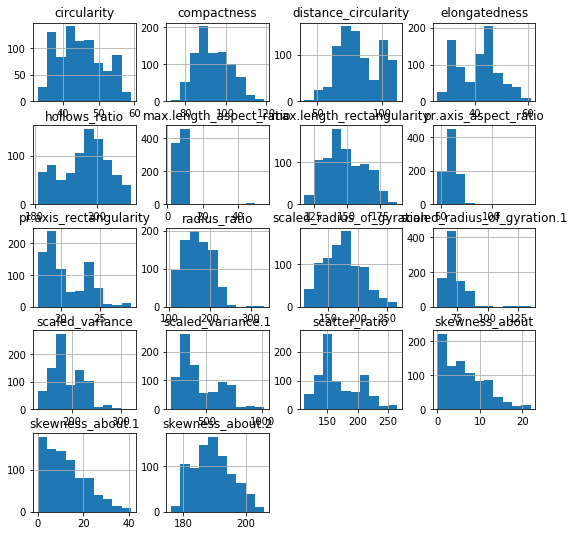

In [10]:
df.hist(figsize=(9, 9))

In [11]:
df.isnull().sum()
df
#now the null values are replaced with mean

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.000000,83.0,178.000000,72.00000,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.000000,84.0,141.000000,57.00000,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.000000,106.0,209.000000,66.00000,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.000000,82.0,159.000000,63.00000,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.000000,70.0,205.000000,103.00000,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus
5,107,44.828775,106.0,172.000000,50.00000,6,255.0,26.0,28.0,169,280.0,957.0,264.0,85.0,5.0,9.0,181.0,183,bus
6,97,43.000000,73.0,173.000000,65.00000,6,153.0,42.0,19.0,143,176.0,361.0,172.0,66.0,13.0,1.0,200.0,204,bus
7,90,43.000000,66.0,157.000000,65.00000,9,137.0,48.0,18.0,146,162.0,281.0,164.0,67.0,3.0,3.0,193.0,202,van
8,86,34.000000,62.0,140.000000,61.00000,7,122.0,54.0,17.0,127,141.0,223.0,112.0,64.0,2.0,14.0,200.0,208,van
9,93,44.000000,98.0,168.888095,62.00000,11,183.0,36.0,22.0,146,202.0,505.0,152.0,64.0,4.0,14.0,195.0,204,car


In [12]:
#total classes are three. 
unique_class=list(df['class'].unique())
unique_class

['van', 'car', 'bus']

# removed the columns which had high co-relation between the features.

In [13]:
# finding the co-relation between the features
df.corr()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
compactness,1.000000,0.685421,0.789909,0.689840,0.091704,0.148249,0.812235,-0.788643,0.813636,0.676143,0.762770,0.815901,0.585156,-0.250071,0.235687,0.157387,0.298526,0.365552
circularity,0.685421,1.000000,0.793016,0.620967,0.153362,0.251208,0.848207,-0.821901,0.844972,0.961943,0.796822,0.838525,0.926888,0.052642,0.144394,-0.011851,-0.105645,0.045318
distance_circularity,0.789909,0.793016,1.000000,0.767079,0.158397,0.264550,0.904400,-0.911435,0.893128,0.774669,0.861980,0.887328,0.705953,-0.225852,0.113813,0.265553,0.145563,0.332095
radius_ratio,0.689840,0.620967,0.767079,1.000000,0.663559,0.450036,0.734228,-0.789795,0.708285,0.569205,0.794041,0.720150,0.536536,-0.180819,0.048720,0.173832,0.382129,0.471262
pr.axis_aspect_ratio,0.091704,0.153362,0.158397,0.663559,1.000000,0.648704,0.103715,-0.183264,0.079395,0.127128,0.273414,0.089620,0.122111,0.152776,-0.058481,-0.032134,0.239849,0.267724
max.length_aspect_ratio,0.148249,0.251208,0.264550,0.450036,0.648704,1.000000,0.165967,-0.180041,0.161592,0.305943,0.318955,0.143713,0.189704,0.295574,0.015439,0.043489,-0.026180,0.143919
scatter_ratio,0.812235,0.848207,0.904400,0.734228,0.103715,0.165967,1.000000,-0.970723,0.989370,0.808356,0.948296,0.993784,0.799266,-0.027985,0.074308,0.213127,0.005167,0.118448
elongatedness,-0.788643,-0.821901,-0.911435,-0.789795,-0.183264,-0.180041,-0.970723,1.000000,-0.949077,-0.775519,-0.936715,-0.955074,-0.766029,0.103481,-0.051997,-0.185691,-0.114727,-0.216719
pr.axis_rectangularity,0.813636,0.844972,0.893128,0.708285,0.079395,0.161592,0.989370,-0.949077,1.000000,0.811447,0.934568,0.989490,0.797068,-0.015676,0.082974,0.214734,-0.018990,0.099191
max.length_rectangularity,0.676143,0.961943,0.774669,0.569205,0.127128,0.305943,0.808356,-0.775519,0.811447,1.000000,0.745209,0.796018,0.866425,0.041220,0.135745,0.001658,-0.104254,0.076770


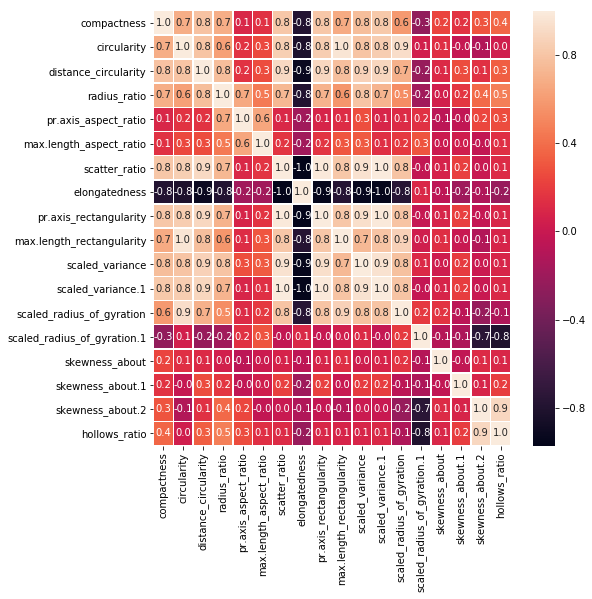

In [14]:
f,ax=plt.subplots(figsize=(8,8))
sns.heatmap(df.corr(),annot=True,linewidth=.5,fmt='.1f',ax=ax)
plt.show()

In [15]:
df.pop('class')
df.pop('elongatedness')
df.pop('scaled_variance')

0      176.0
1      170.0
2      223.0
3      160.0
4      241.0
5      280.0
6      176.0
7      162.0
8      141.0
9      202.0
10     153.0
11     148.0
12     180.0
13     173.0
14     196.0
15     227.0
16     137.0
17     202.0
18     225.0
19     227.0
20     175.0
21     141.0
22     169.0
23     164.0
24     221.0
25     169.0
26     143.0
27     229.0
28     217.0
29     168.0
       ...  
816    175.0
817    226.0
818    217.0
819    206.0
820    158.0
821    223.0
822    163.0
823    214.0
824    225.0
825    185.0
826    200.0
827    223.0
828    162.0
829    173.0
830    167.0
831    179.0
832    229.0
833    185.0
834    150.0
835    285.0
836    168.0
837    181.0
838    173.0
839    159.0
840    151.0
841    200.0
842    173.0
843    228.0
844    155.0
845    140.0
Name: scaled_variance, Length: 846, dtype: float64

In [16]:
df.pop('distance_circularity')
df.pop('scaled_variance.1')

0       379.0
1       330.0
2       635.0
3       309.0
4       325.0
5       957.0
6       361.0
7       281.0
8       223.0
9       505.0
10      266.0
11      224.0
12      349.0
13      345.0
14      465.0
15      624.0
16      206.0
17      485.0
18      686.0
19      651.0
20      354.0
21      221.0
22      344.0
23      307.0
24      623.0
25      324.0
26      238.0
27      696.0
28      570.0
29      314.0
        ...  
816     375.0
817     707.0
818     534.0
819     508.0
820     277.0
821     713.0
822     314.0
823     597.0
824     717.0
825     358.0
826     478.0
827     726.0
828     254.0
829     365.0
830     346.0
831     406.0
832     665.0
833     382.0
834     268.0
835    1018.0
836     294.0
837     373.0
838     339.0
839     283.0
840     251.0
841     422.0
842     368.0
843     721.0
844     270.0
845     212.0
Name: scaled_variance.1, Length: 846, dtype: float64

In [17]:
df.pop('max.length_rectangularity')
df.pop('pr.axis_rectangularity')

0      20.0
1      19.0
2      23.0
3      19.0
4      19.0
5      28.0
6      19.0
7      18.0
8      17.0
9      22.0
10     18.0
11     17.0
12     19.0
13     19.0
14     21.0
15     23.0
16     17.0
17     21.0
18     24.0
19     24.0
20     19.0
21     17.0
22     19.0
23     18.0
24     23.0
25     19.0
26     18.0
27     25.0
28     22.0
29     19.0
       ... 
816    20.0
817    25.0
818    22.0
819    22.0
820    18.0
821    25.0
822    19.0
823    23.0
824    25.0
825    20.0
826    21.0
827    25.0
828    18.0
829    20.0
830    19.0
831    20.0
832    24.0
833    20.0
834    18.0
835    29.0
836    18.0
837    20.0
838    19.0
839    18.0
840    18.0
841    20.0
842    20.0
843    25.0
844    18.0
845    17.0
Name: pr.axis_rectangularity, Length: 846, dtype: float64

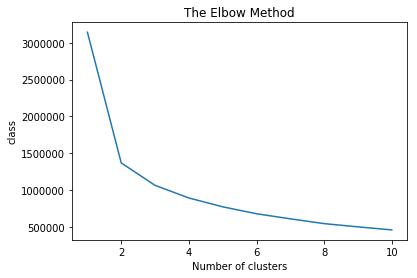

In [18]:
# Using the elbow method to find  the optimal number of clusters
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init='k-means++',max_iter=300,n_init=10,random_state=0)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('class')
plt.show()

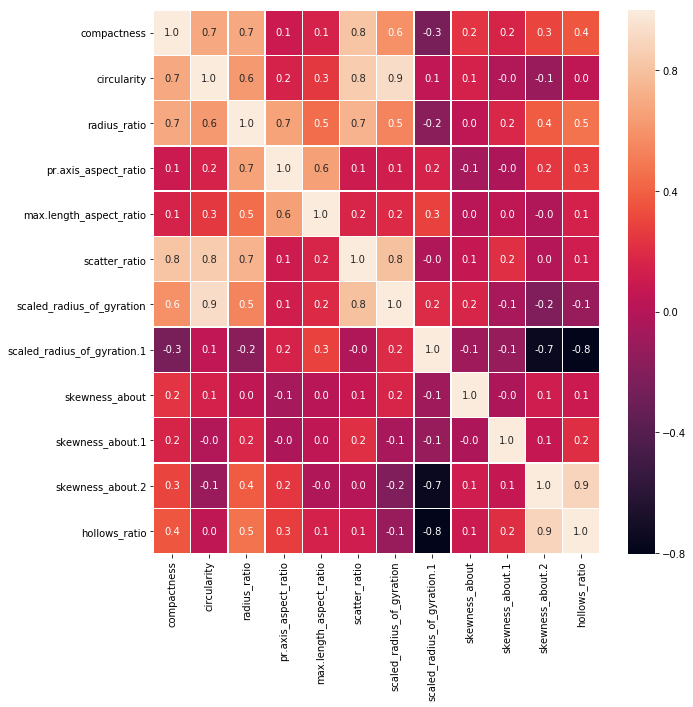

In [19]:
f,ax=plt.subplots(figsize=(10,10))
sns.heatmap(df.corr(),annot=True,linewidth=.5,fmt='.1f',ax=ax)
plt.show()

In [20]:
df.columns
#final columns present in the dataframe

Index(['compactness', 'circularity', 'radius_ratio', 'pr.axis_aspect_ratio',
       'max.length_aspect_ratio', 'scatter_ratio', 'scaled_radius_of_gyration',
       'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1',
       'skewness_about.2', 'hollows_ratio'],
      dtype='object')

In [21]:
vehicle_df = pd.read_csv("vehicle.csv")

In [22]:
x=df
y=vehicle_df['class']

In [23]:
# We transform (centralize) the entire X (independent variable data) to zscores through transformation. We will create the PCA dimensions
# on this distribution. 
sc = StandardScaler()
X_std =  sc.fit_transform(x)          
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[ 1.00118343  0.68623251  0.69065619  0.09181254  0.14842463  0.81319623
   0.58584865 -0.25036693  0.23596607  0.15757316  0.2988797   0.36598446]
 [ 0.68623251  1.00118343  0.62170187  0.15354334  0.25150523  0.84921058
   0.92798524  0.05270433  0.14456452 -0.01186527 -0.1057698   0.04537164]
 [ 0.69065619  0.62170187  1.00118343  0.6643445   0.45056889  0.73509724
   0.5371705  -0.1810333   0.04877731  0.17403799  0.38258162  0.47181974]
 [ 0.09181254  0.15354334  0.6643445   1.00118343  0.64947191  0.1038381
   0.12225517  0.15295712 -0.05855013 -0.0321716   0.24013301  0.26804079]
 [ 0.14842463  0.25150523  0.45056889  0.64947191  1.00118343  0.16616348
   0.18992805  0.29592367  0.01545721  0.04354026 -0.02621063  0.14408905]
 [ 0.81319623  0.84921058  0.73509724  0.1038381   0.16616348  1.00118343
   0.80021174 -0.02801827  0.07439557  0.213379    0.00517279  0.11858838]
 [ 0.58584865  0.92798524  0.5371705   0.12225517  0.18992805  0.80021174
   1.001183

C:\Users\selvm\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\preprocessing\data.py:645: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\selvm\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\base.py:464: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


In [24]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[ 0.41171406  0.02597937  0.21891503  0.00291453  0.03379066  0.05922132
   0.69021056  0.02611777  0.53186722 -0.03199151  0.11995274  0.04321734]
 [ 0.4015046  -0.23956535  0.15328809 -0.06307518 -0.11807187  0.17987129
  -0.34365216  0.12929455  0.23733724  0.12049133 -0.58916615 -0.3935154 ]
 [ 0.43954779  0.06437011 -0.20338303  0.06281487 -0.06740078 -0.3336923
   0.04371848 -0.32260309 -0.23694934  0.68534487  0.09353339 -0.02958572]
 [ 0.20400188  0.04004906 -0.62618939 -0.08857781 -0.02755913 -0.4649846
  -0.15045832 -0.07349179  0.33670364 -0.44084899 -0.06159521  0.017322  ]
 [ 0.19189243 -0.0923182  -0.56418394 -0.03885149  0.22571767  0.70427366
   0.08833207 -0.06078938 -0.14377381 -0.02754327  0.17284219 -0.1583981 ]
 [ 0.42125974 -0.15984163  0.19958537  0.17601968 -0.05670361 -0.06002195
   0.16040955 -0.18271959 -0.59178044 -0.52008155 -0.16959199  0.10386373]
 [ 0.3577631  -0.31702644  0.16329997 -0.09727186 -0.09772067  0.00894273
  -0.42311665  0

In [25]:
#Sort eigenvalues in descending order

# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(4.304066895734707, array([ 0.41171406,  0.4015046 ,  0.43954779,  0.20400188,  0.19189243,
        0.42125974,  0.3577631 , -0.096461  ,  0.09147   ,  0.08252094,
        0.14956715,  0.21292752])), (2.859792302289707, array([ 0.02597937, -0.23956535,  0.06437011,  0.04004906, -0.0923182 ,
       -0.15984163, -0.31702644, -0.50049679,  0.03057661,  0.10985128,
        0.52864108,  0.50857415])), (1.785343093188125, array([ 0.21891503,  0.15328809, -0.20338303, -0.62618939, -0.56418394,
        0.19958537,  0.16329997, -0.2627601 ,  0.1873023 ,  0.05108612,
       -0.02982543, -0.05169207])), (1.0821047083320023, array([ 0.00291453, -0.06307518,  0.06281487, -0.08857781, -0.03885149,
        0.17601968, -0.09727186,  0.02241356, -0.59852607,  0.75348738,
       -0.12424079, -0.01876899])), (0.9033330892349445, array([ 0.03379066, -0.11807187, -0.06740078, -0.02755913,  0.22571767,
       -0.05670361, -0.09772067,  0.14539039,  0.7443849 ,  0.57688697,
       -0.08605096, -0.02124038])

In [26]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  
cum_var_exp = np.cumsum(var_explained)  
tot
cum_var_exp

array([0.35824828, 0.59628261, 0.74488534, 0.83495414, 0.91014292,
       0.94279588, 0.96949168, 0.98203721, 0.99025379, 0.994768  ,
       0.99831319, 1.        ])

ValueError: shape mismatch: objects cannot be broadcast to a single shape

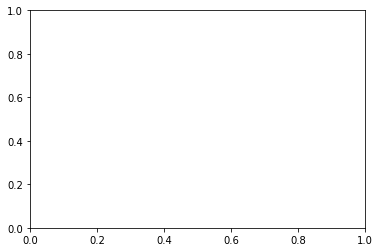

In [27]:
plt.bar(range(1,12), var_explained, alpha=0.6, align='center', label='individual explained variance')
plt.step(range(1,12),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc ='best')
plt.show()

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

test_size = 0.25
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=test_size)

In [ ]:
trainedsvm =SVC().fit(X_train, Y_train)
predictionsvm = trainedsvm.predict(X_test)
model = SVC(kernel='linear', C=1E10)
model.fit(x,y)

C:\Users\selvm\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [1.0, 10.0, 50.0],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'shrinking': [True, False],
    'gamma': ['auto', 1, 0.1],
    'coef0': [0.0, 0.1, 0.5]
}

model_svc = SVC()

grid_search = GridSearchCV(
    model_svc, param_grid, cv=10, scoring='accuracy')
grid_search.fit(x,y)